# Answer Key: U.S. Cities Map — Population Symbol Map

**Challenge:** Design and implement an appropriate Python data structure to represent data on 10 U.S. cities (name, latitude, longitude, population, region), then visualize the data on a map where population is represented by symbol size.

In [1]:
!wget https://github.com/SpatialTurn/IGIC2026/raw/main/episodes/statesboundary.zip
!unzip statesboundary.zip -d statesboundary
!rm statesboundary.zip

--2026-05-07 04:32:39--  https://github.com/SpatialTurn/IGIC2026/raw/main/episodes/statesboundary.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/SpatialTurn/IGIC2026/main/episodes/statesboundary.zip [following]
--2026-05-07 04:32:40--  https://raw.githubusercontent.com/SpatialTurn/IGIC2026/main/episodes/statesboundary.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6314677 (6.0M) [application/zip]
Saving to: ‘statesboundary.zip’

statesboundary.zip  100%[===================>]   6.02M  32.0MB/s    in 0.2s    

2026-05-07 04:32:41 (32.0 MB/s) - ‘statesboundary.zip’ saved [6314677/6314677]

## Option A: Simple Lists `[]`

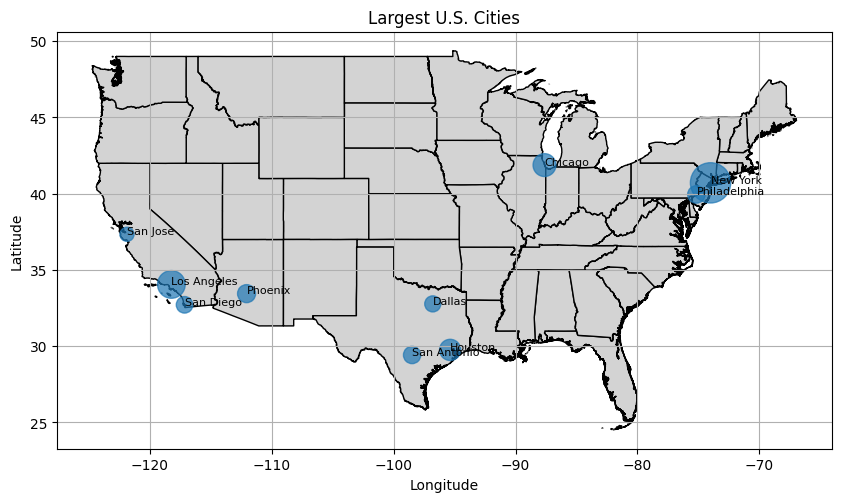

In [4]:
import matplotlib.pyplot as plt
import geopandas as gpd

states = gpd.read_file("statesboundary/statesusa.shp")

# City data
cities = [
    "New York", "Los Angeles", "Chicago", "Houston", "Phoenix",
    "Philadelphia", "San Antonio", "San Diego", "Dallas", "San Jose"
]

latitudes = [
    40.7128, 34.0522, 41.8781, 29.7604, 33.4484,
    39.9526, 29.4241, 32.7157, 32.7767, 37.3382
]

longitudes = [
    -74.0060, -118.2437, -87.6298, -95.3698, -112.0740,
    -75.1652, -98.4936, -117.1611, -96.7970, -121.8863
]

populations = [
    8419600, 3980400, 2716000, 2328000, 1690000,
    1584200, 1547200, 1423800, 1341000, 1035500
]

# Make bubble sizes smaller
sizes = [pop / 10000 for pop in populations]

# Create plot
plt.figure(figsize=(10, 6))

# Plot the states
states.plot(ax=plt.gca(), color='lightgray', edgecolor='black')

plt.scatter(longitudes, latitudes, s=sizes, alpha=0.7)

# Add city labels
for i in range(len(cities)):
    plt.text(longitudes[i], latitudes[i], cities[i], fontsize=8)

# Titles and labels
plt.title("Largest U.S. Cities")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.show()

## Option B: Dictionaries `{}` -> Convert to DataFrame

           City  Latitude  Longitude  Population
0      New York   40.7128   -74.0060     8419600
1   Los Angeles   34.0522  -118.2437     3980400
2       Chicago   41.8781   -87.6298     2716000
3       Houston   29.7604   -95.3698     2328000
4       Phoenix   33.4484  -112.0740     1690000
5  Philadelphia   39.9526   -75.1652     1584200
6   San Antonio   29.4241   -98.4936     1547200
7     San Diego   32.7157  -117.1611     1423800
8        Dallas   32.7767   -96.7970     1341000
9      San Jose   37.3382  -121.8863     1035500


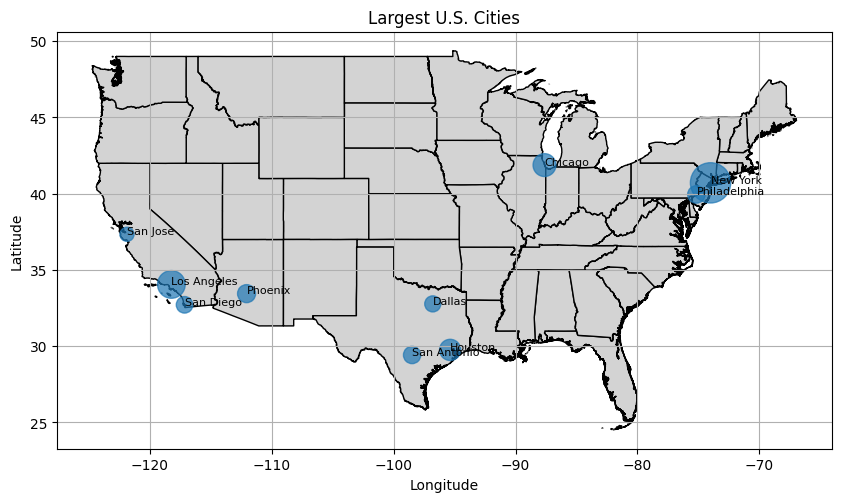

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

states = gpd.read_file("statesboundary/statesusa.shp") # read the state boundary shape file

# Create a dictionary with the data
data = {
    "City": [
        "New York", "Los Angeles", "Chicago", "Houston", "Phoenix",
        "Philadelphia", "San Antonio", "San Diego", "Dallas", "San Jose"
    ],

    "Latitude": [
        40.7128, 34.0522, 41.8781, 29.7604, 33.4484,
        39.9526, 29.4241, 32.7157, 32.7767, 37.3382
    ],

    "Longitude": [
        -74.0060, -118.2437, -87.6298, -95.3698, -112.0740,
        -75.1652, -98.4936, -117.1611, -96.7970, -121.8863
    ],

    "Population": [
        8419600, 3980400, 2716000, 2328000, 1690000,
        1584200, 1547200, 1423800, 1341000, 1035500
    ]
}

# Convert dictionary into a DataFrame
df = pd.DataFrame(data)

# Show the table
print(df)

# Create bubble sizes
sizes = df["Population"] / 10000

# Create plot
plt.figure(figsize=(10, 6))

states.plot(ax=plt.gca(), color='lightgray', edgecolor='black')

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    s=sizes,
    alpha=0.7
)

# Add labels
for i in range(len(df)):
    plt.text(
        df["Longitude"][i],
        df["Latitude"][i],
        df["City"][i],
        fontsize=8
    )

# Titles and labels
plt.title("Largest U.S. Cities")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.show()